### ***Community Solar Farm Energy Analysis***

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
np.random.seed(42)

days = 365

data = {
    "Date": pd.date_range(start="2025-01-01", periods=days),
    "Households": np.random.randint(90,110,days),
    "Solar_Generation_kWh": np.random.normal(1200,200,days),
    "Consumption_kWh": np.random.normal(1500,250,days),
    "Battery_Storage_kWh": np.random.normal(400,60,days)
}

df = pd.DataFrame(data)

df["Grid_Usage_kWh"] = df["Consumption_kWh"] - df["Solar_Generation_kWh"]
df["Grid_Usage_kWh"] = df["Grid_Usage_kWh"].clip(lower=0)

electricity_rate = 8

df["Electricity_Cost"] = df["Grid_Usage_kWh"] * electricity_rate

df.head()



,Date,Households,Solar_Generation_kWh,Consumption_kWh,Battery_Storage_kWh,Grid_Usage_kWh,Electricity_Cost
0,2025-01-01,96,1126.310002,1403.615440,310.793753,277.305438,2218.443503
1,2025-01-02,109,1231.440371,1832.609641,418.985564,601.169270,4809.354158
2,2025-01-03,104,1176.905318,1999.829302,426.679311,822.923984,6583.391868
3,2025-01-04,100,1366.341715,1679.524637,340.278678,313.182922,2505.463373
4,2025-01-05,97,1136.128984,1891.898605,453.444285,755.769621,6046.156966


In [10]:
df.to_csv("solar_dataset.csv", index=False)

In [11]:
from google.colab import files
files.download("solar_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
uploaded = files.upload()

Saving solar_dataset.csv to solar_dataset (1).csv


In [13]:
df = pd.read_csv("solar_dataset.csv")
df.head()

,Date,Households,Solar_Generation_kWh,Consumption_kWh,Battery_Storage_kWh,Grid_Usage_kWh,Electricity_Cost
0,2025-01-01,96,1126.310002,1403.615440,310.793753,277.305438,2218.443503
1,2025-01-02,109,1231.440371,1832.609641,418.985564,601.169270,4809.354158
2,2025-01-03,104,1176.905318,1999.829302,426.679311,822.923984,6583.391868
3,2025-01-04,100,1366.341715,1679.524637,340.278678,313.182922,2505.463373
4,2025-01-05,97,1136.128984,1891.898605,453.444285,755.769621,6046.156966


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  365 non-null    object 
 1   Households            365 non-null    int64  
 2   Solar_Generation_kWh  365 non-null    float64
 3   Consumption_kWh       365 non-null    float64
 4   Battery_Storage_kWh   365 non-null    float64
 5   Grid_Usage_kWh        365 non-null    float64
 6   Electricity_Cost      365 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 20.1+ KB


In [15]:
df.describe()

,Households,Solar_Generation_kWh,Consumption_kWh,Battery_Storage_kWh,Grid_Usage_kWh,Electricity_Cost
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,99.093151,1216.837863,1504.614060,401.238073,322.081027,2576.648214
std,6.050346,219.191363,246.160144,66.611652,274.842401,2198.739205
min,90.000000,504.366157,607.948675,196.694315,0.000000,0.000000
25%,94.000000,1075.196654,1348.734231,359.077937,68.640736,549.125884
50%,99.000000,1229.040812,1509.719402,403.831378,299.997622,2399.980972
75%,105.000000,1349.821135,1672.465812,447.772529,487.384189,3899.073514
max,109.000000,1850.797025,2190.190484,588.518019,1248.169208,9985.353663


In [16]:
total_solar = df["Solar_Generation_kWh"].sum()
total_consumption = df["Consumption_kWh"].sum()
total_grid = df["Grid_Usage_kWh"].sum()
total_cost = df["Electricity_Cost"].sum()

print("Total Solar Energy Generated:", total_solar)
print("Total Energy Consumed:", total_consumption)
print("Total Grid Electricity Used:", total_grid)
print("Total Electricity Cost:", total_cost)

Total Solar Energy Generated: 444145.81998739333
Total Energy Consumed: 549184.1318634542
Total Grid Electricity Used: 117559.57474267506
Total Electricity Cost: 940476.5979414005


In [17]:
solar_percentage = (total_solar / total_consumption) * 100

print("Solar Energy Contribution:", solar_percentage, "%")

Solar Energy Contribution: 80.87375330389608 %


In [18]:
grid_percentage = (total_grid / total_consumption) * 100

print("Grid Dependency:", grid_percentage, "%")

Grid Dependency: 21.406222052297817 %


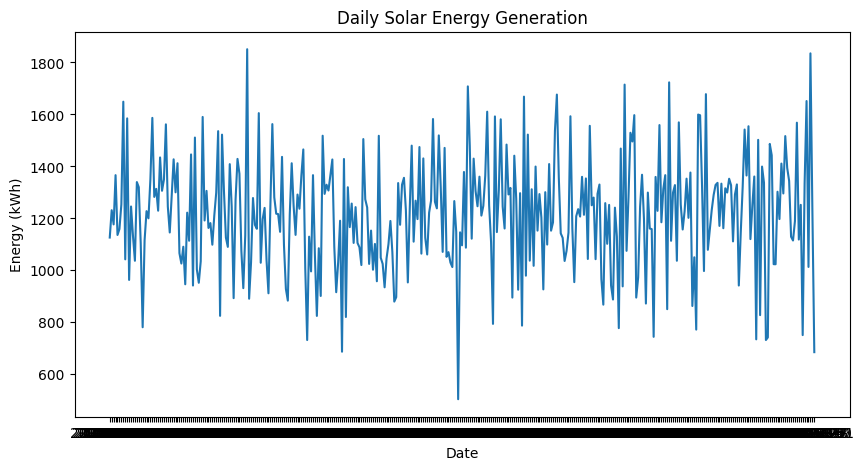

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Solar_Generation_kWh"])

plt.title("Daily Solar Energy Generation")

plt.xlabel("Date")

plt.ylabel("Energy (kWh)")

plt.show()

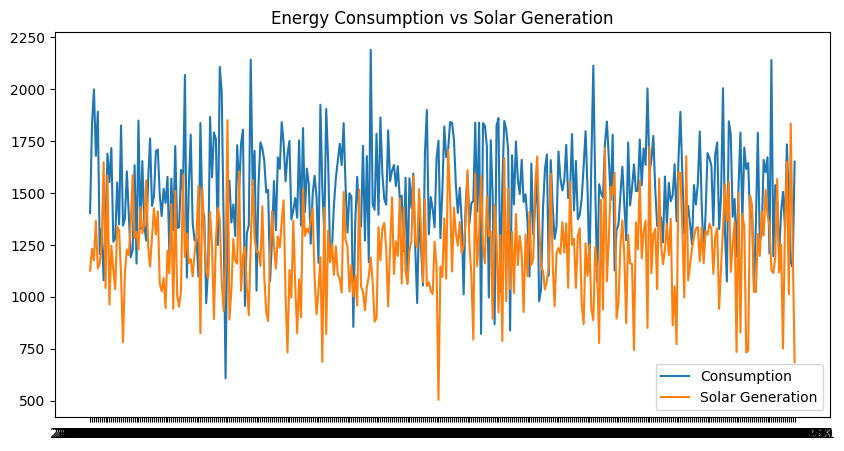

In [20]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Consumption_kWh"], label="Consumption")

plt.plot(df["Date"], df["Solar_Generation_kWh"], label="Solar Generation")

plt.legend()

plt.title("Energy Consumption vs Solar Generation")

plt.show()

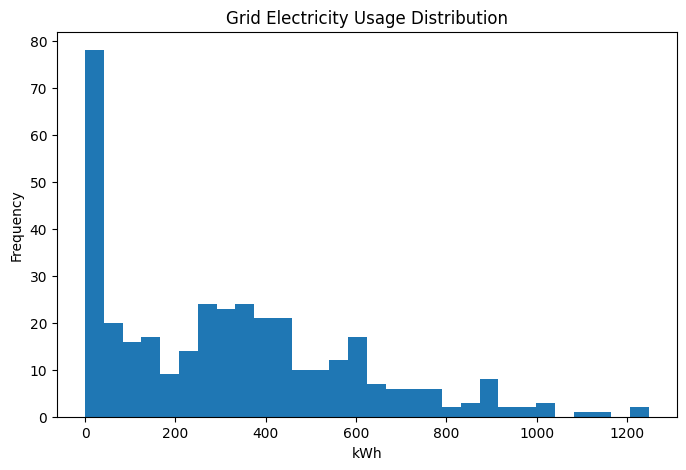

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Grid_Usage_kWh"], bins=30)

plt.title("Grid Electricity Usage Distribution")

plt.xlabel("kWh")

plt.ylabel("Frequency")

plt.show()

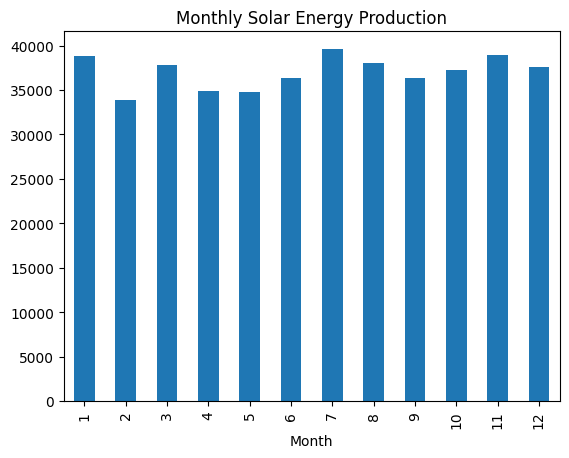

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

monthly_solar = df.groupby("Month")["Solar_Generation_kWh"].sum()

monthly_solar.plot(kind="bar")

plt.title("Monthly Solar Energy Production")

plt.show()

In [23]:
investment = 8000000

annual_cost_before = 3000000

annual_savings = annual_cost_before * 0.5

net_benefit = annual_savings - investment

print("Annual Savings:", annual_savings)
print("Net Benefit Year 1:", net_benefit)

Annual Savings: 1500000.0
Net Benefit Year 1: -6500000.0


In [24]:
total_savings = annual_savings * 25

profit = total_savings - investment

print("Total Savings in 25 Years:", total_savings)
print("Total Profit:", profit)

Total Savings in 25 Years: 37500000.0
Total Profit: 29500000.0


**Energy reliability improves** </br>
Because solar reduces grid dependency.</br>

---


**Electricity cost reduces**</br>
Solar reduces electricity bills by 50%.</br>

---


**Community benefits**</br>
Clean renewable energy reduces pollution.

---



In [25]:
plt.savefig("solar_generation_chart.png")

<Figure size 640x480 with 0 Axes>

In [26]:
from google.colab import files
files.download("solar_generation_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Consumption_kWh","Battery_Storage_kWh"]]
y = df["Solar_Generation_kWh"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

In [29]:
print(predictions)

[1253.09333045 1229.35697943 1210.08546536 1173.48207003 1226.92991699
 1235.86585064 1201.72707877 1214.5580766  1210.25343392 1228.02432736
 1219.52116639 1254.70360617 1231.16725109 1219.51926998 1202.84794915
 1198.83327236 1229.45886069 1227.41152603 1216.10230484 1215.99068611
 1204.58540979 1215.62424917 1234.25853337 1220.7640197  1261.89046958
 1216.66835152 1214.67847085 1248.71491352 1212.92364419 1220.47242429
 1209.00308062 1236.02062123 1180.69592942 1215.65186239 1214.18434003
 1214.94709077 1243.80256203 1205.11046815 1190.38304622 1200.42241929
 1243.70375312 1204.22507009 1230.99676143 1232.25701836 1212.01815482
 1199.21818252 1226.51978473 1189.61757509 1241.797577   1231.26863011
 1222.98399521 1214.11431464 1221.31950759 1220.4085662  1235.18244728
 1247.08062531 1237.44716857 1229.33121455 1235.96937426 1232.1349352
 1217.06524037 1244.01401372 1230.98625334 1246.73642286 1212.50154634
 1218.80178533 1259.83916155 1239.84440212 1220.7148732  1234.20142862
 1207.7

In [30]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head()

,Actual,Predicted
329,1364.980037,1253.093330
265,938.468586,1229.356979
228,1152.828038,1210.085465
131,1505.165991,1173.482070
344,1023.624221,1226.929917


In [31]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test,predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 155.50704166706333


A Linear Regression model was trained using energy consumption and battery storage as input variables to predict solar energy generation. The dataset was split into 80% training and 20% testing data. The model predictions were evaluated using Mean Absolute Error.

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 155.50704166706333
R2 Score: -0.011245050820599234


In [33]:
results = pd.DataFrame({
    "Actual_Solar": y_test,
    "Predicted_Solar": predictions
})

results.head()

,Actual_Solar,Predicted_Solar
329,1364.980037,1253.093330
265,938.468586,1229.356979
228,1152.828038,1210.085465
131,1505.165991,1173.482070
344,1023.624221,1226.929917


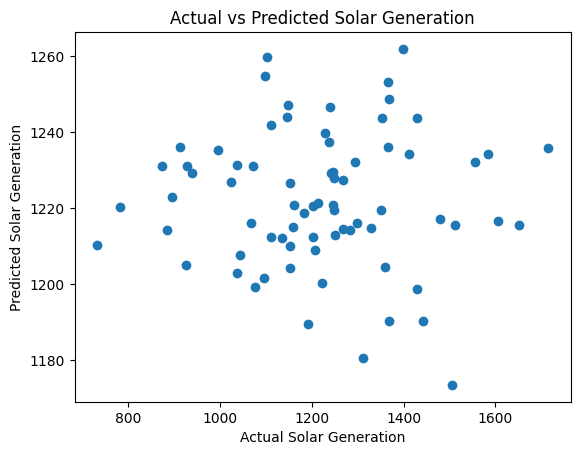

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

plt.xlabel("Actual Solar Generation")

plt.ylabel("Predicted Solar Generation")

plt.title("Actual vs Predicted Solar Generation")

plt.show()

In [35]:
solar_total = df["Solar_Generation_kWh"].sum()
consumption_total = df["Consumption_kWh"].sum()

solar_share = (solar_total / consumption_total) * 100

print("Solar Contribution %:", solar_share)

Solar Contribution %: 80.87375330389608


In [36]:
grid_total = df["Grid_Usage_kWh"].sum()

grid_dependency = (grid_total / consumption_total) * 100

print("Grid Dependency %:", grid_dependency)


Grid Dependency %: 21.406222052297817


In [37]:
annual_cost_before = 3000000

annual_cost_after = annual_cost_before * 0.5

savings = annual_cost_before - annual_cost_after

print("Annual Savings:", savings)

Annual Savings: 1500000.0


In [38]:
investment = 8000000

net_benefit = savings - investment

print("Net Benefit Year 1:", net_benefit)

Net Benefit Year 1: -6500000.0


But solar projects are long-term investments.

In [39]:
total_savings_25 = savings * 25

profit = total_savings_25 - investment

print("25 Year Profit:", profit)

25 Year Profit: 29500000.0
